<a href="https://colab.research.google.com/github/dnlsantos78a/project-2-sample/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from os import path
path = "/content/drive/MyDrive/Data Bases /data_base_payments.csv"
df = pd.read_csv(path, encoding='latin1')
df.head()

,Date,Period,Type,Document Number,Account,Amount,Amount (Foreign Currency),Currency,Customer Internal ID,Core Client ID,...,Month_Name,Month_Num,ISO Year-Week,ISO Week Anchor,ISO Week Month,ISO Week Month Sort,ISO Quarter,ISO Quarter Sort,Client_name,Entity_name
0,01/01/2025,01/25/2026,Payment,PMT970445361051537676,10303,324.92,324.92,USD,30878703,36903.0,...,Jan,1,2025-W01,45659,Jan 2025,202501,2025-Q1,20251,Client_A1,Entity_B001
1,01/01/2025,01/25/2026,Payment,PMT970445361051537775,10310,47.68,£38.00,GBP,13978091,45273.0,...,Jan,1,2025-W01,45659,Jan 2025,202501,2025-Q1,20251,Client_A2,Entity_B002
2,01/01/2025,01/25/2026,Payment,PMT970445361051537776,10310,435.13,£346.80,GBP,13978091,45273.0,...,Jan,1,2025-W01,45659,Jan 2025,202501,2025-Q1,20251,Client_A2,Entity_B002
3,01/01/2025,01/25/2026,Payment,PMT970445361051537777,10310,8949.16,"£7,132.51",GBP,13978091,45273.0,...,Jan,1,2025-W01,45659,Jan 2025,202501,2025-Q1,20251,Client_A2,Entity_B002
4,01/01/2025,01/25/2026,Payment,PMT970445361051537778,10310,1582.77,"£1,261.47",GBP,13978091,45273.0,...,Jan,1,2025-W01,45659,Jan 2025,202501,2025-Q1,20251,Client_A2,Entity_B002


**1. DATA SANITY AND STRUCTURE**

In [ ]:
df.describe().style.format("{:,.2f}")



,Account,Amount,Customer Internal ID,Core Client ID,Cored_ID,Day_Num,Day_Nam_Sort,Month_Num,ISO Week Anchor,ISO Week Month Sort,ISO Quarter Sort
count,"30,709.00","30,709.00","30,709.00","30,691.00","30,709.00","30,709.00","30,709.00","30,709.00","30,709.00","30,709.00","30,709.00"
mean,"10,073.71","21,550.36","26,858,520.03","106,096.73","106,143.54",15.65,3.18,6.88,"45,851.48","202,507.79","20,252.71"
std,72.54,"63,882.27","6,837,427.34","82,972.76","83,003.15",8.75,1.49,3.35,102.26,9.93,1.37
min,"10,020.00",0.01,"7,664.00",963.00,963.00,1.00,1.00,1.00,"45,659.00","202,501.00","20,251.00"
25%,"10,051.00","1,353.61","25,730,859.00","55,296.00","55,296.00",8.00,2.00,4.00,"45,764.00","202,504.00","20,252.00"
50%,"10,051.00","5,153.40","29,229,474.00","77,488.00","77,488.00",16.00,3.00,7.00,"45,855.00","202,507.00","20,253.00"
75%,"10,053.00","16,153.97","31,420,378.00","97,750.00","97,750.00",23.00,5.00,10.00,"45,939.00","202,510.00","20,254.00"
max,"10,310.00","3,333,246.68","32,495,438.00","280,852.00","281,530.00",31.00,7.00,12.00,"46,023.00","202,601.00","20,261.00"


In [ ]:
df.shape

(30709, 25)

In [ ]:
df.columns

Index(['Date', 'Period', 'Type', 'Document Number', 'Account', 'Amount',
       'Amount (Foreign Currency)', 'Currency', 'Customer Internal ID',
       'Core Client ID', 'Cored_ID', 'Day_Num', 'Day_Label', 'Day Name',
       'Day_Nam_Sort', 'Month_Name', 'Month_Num', 'ISO Year-Week',
       'ISO Week Anchor', 'ISO Week Month', 'ISO Week Month Sort',
       'ISO Quarter', 'ISO Quarter Sort', 'Client_name', 'Entity_name'],
      dtype='object')

**2. DATA QUALITY AND CHECKS**

In [ ]:
df.isna().sum()

,0
Date,0
Period,0
Type,0
Document Number,417
Account,0
Amount,0
Amount (Foreign Currency),755
Currency,0
Customer Internal ID,0
Core Client ID,18


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30709 entries, 0 to 30708
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       30709 non-null  object 
 1   Period                     30709 non-null  object 
 2   Type                       30709 non-null  object 
 3   Document Number            30292 non-null  object 
 4   Account                    30709 non-null  int64  
 5   Amount                     30709 non-null  float64
 6   Amount (Foreign Currency)  29954 non-null  object 
 7   Currency                   30709 non-null  object 
 8   Customer Internal ID       30709 non-null  int64  
 9   Core Client ID             30691 non-null  float64
 10  Cored_ID                   30709 non-null  int64  
 11  Day_Num                    30709 non-null  int64  
 12  Day_Label                  30709 non-null  object 
 13  Day Name                   30709 non-null  obj

3. **Time coverage & continuity**

In [ ]:
df['Date'].min(), df['Date'].max()

('01/01/2025', '12/31/2025')

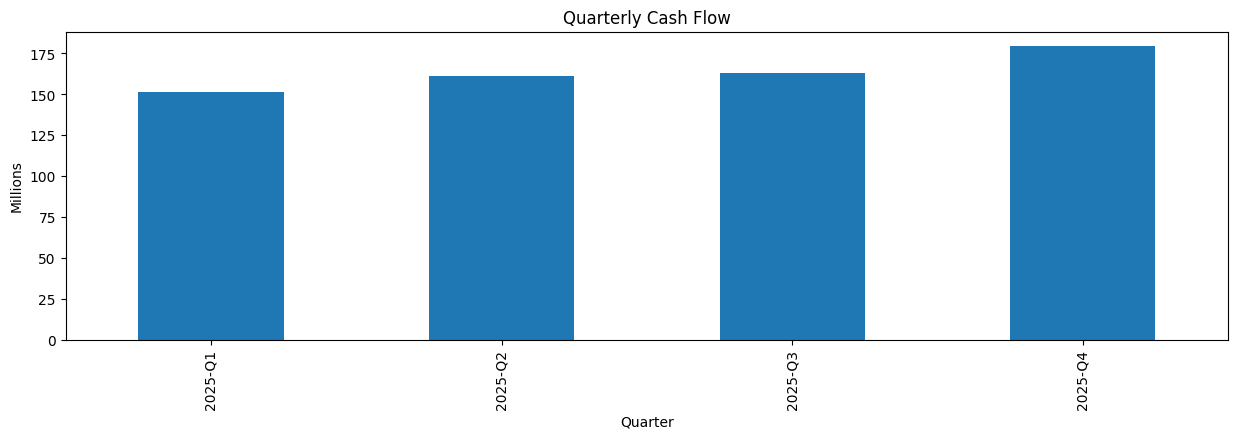

In [ ]:
ax = (
    df[df['ISO Quarter'] != '2026-Q1']
      .groupby('ISO Quarter', as_index=True)['Amount']
      .sum()
      .div(1_000_000)
      .plot(kind='bar', figsize=(15,4))
)

ax.set_title('Quarterly Cash Flow')
ax.set_xlabel('Quarter')
ax.set_ylabel('Millions')
ax.ticklabel_format(style='plain', axis='y')


Text(0, 0.5, 'Millions')

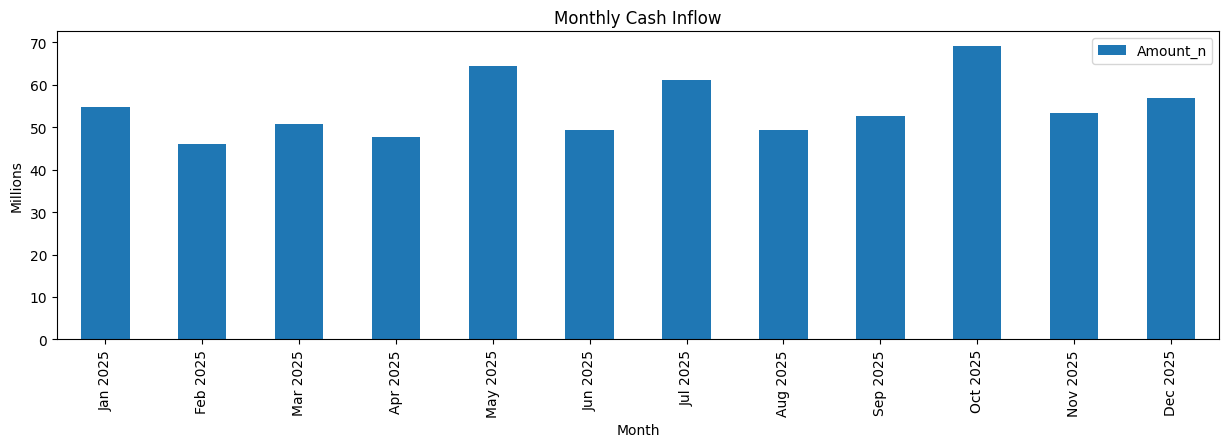

In [ ]:
Monthly = df[df['ISO Week Month'] != 'Jan 2026'] \
            .groupby('ISO Week Month', as_index=False)['Amount'] \
            .sum() \

Monthly['Amount_n'] = Monthly['Amount']/ 1000000

Monthly['ISO Week Month'] = pd.to_datetime(Monthly['ISO Week Month'],format='%b %Y')

Monthly = Monthly.sort_values('ISO Week Month')

Monthly['Month_Label'] = Monthly['ISO Week Month'].dt.strftime('%b %Y')

ax = Monthly.plot(x='Month_Label', y='Amount_n', kind='bar', figsize=(15,4))

ax.set_title('Monthly Cash Inflow')
ax.set_xlabel('Month')
ax.set_ylabel('Millions')

Text(0.5, 1.0, 'Weekly Amount by ISO Week')

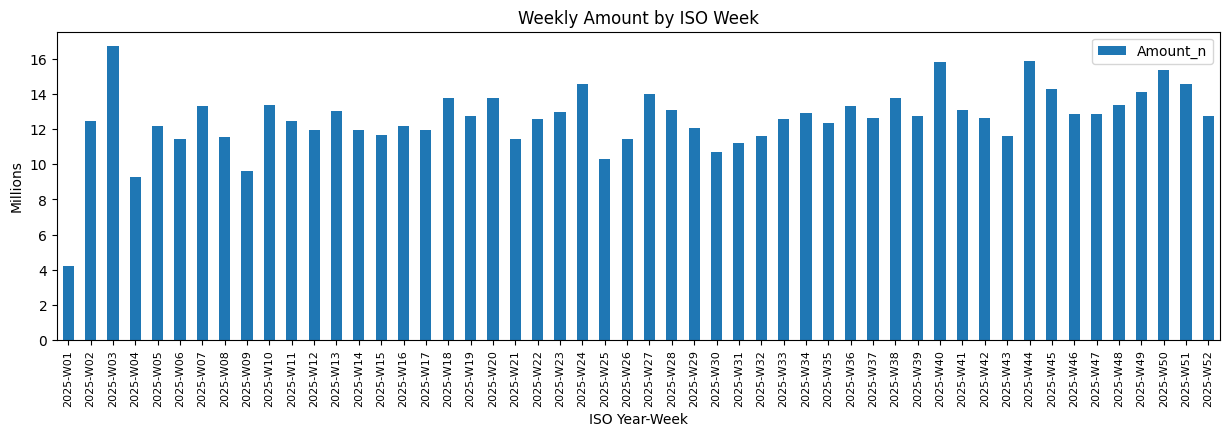

In [ ]:
weekly = df[df['ISO Year-Week'] != '2026-W53']\
      .groupby('ISO Year-Week', as_index=False)['Amount']\
      .sum()\
      .sort_values('ISO Year-Week') \

weekly['Amount_n'] = weekly['Amount']/ 1000000

ax = weekly.plot(x='ISO Year-Week', y='Amount_n', kind='bar',figsize=(15,4))

ax.set_xticklabels(weekly['ISO Year-Week'], rotation=90, fontsize=8)
ax.set_ylabel('Millions')
ax.set_title('Weekly Amount by ISO Week')



In [ ]:
Weekly_d = ( df[df['ISO Year-Week'] != '2026-W53']\
.groupby('ISO Year-Week', as_index=False)['Amount'].sum()\
.sort_values('ISO Year-Week') )

weekly_mean = Weekly_d['Amount'].mean()
weekly_std = Weekly_d['Amount'].std()
cv = weekly_std / weekly_mean


print(f"Weekly average inflow: {weekly_mean:,.0f}")
print(f"Weekly standard deviation: {weekly_std:,.0f}")
print(f"Coefficient of variation: {cv:.1%}")

Weekly average inflow: 12,608,124
Weekly standard deviation: 1,880,578
Coefficient of variation: 14.9%


   ISO Week Month        Amount Month_Label   rolling_std
4      2025-01-01  5.482982e+07    Jan 2025           NaN
3      2025-02-01  4.599804e+07    Feb 2025           NaN
8      2025-03-01  5.086947e+07    Mar 2025  4.423711e+06
0      2025-04-01  4.779408e+07    Apr 2025  2.463555e+06
9      2025-05-01  6.439125e+07    May 2025  8.829516e+06
7      2025-06-01  4.926854e+07    Jun 2025  9.186368e+06
6      2025-07-01  6.107511e+07    Jul 2025  7.948671e+06
1      2025-08-01  4.945595e+07    Aug 2025  6.763077e+06
12     2025-09-01  5.254723e+07    Sep 2025  6.017831e+06
11     2025-10-01  6.912289e+07    Oct 2025  1.057589e+07
10     2025-11-01  5.342689e+07    Nov 2025  9.326402e+06
2      2025-12-01  5.684317e+07    Dec 2025  8.254561e+06
5      2026-01-01  6.167531e+06    Jan 2026  2.832295e+07


<Axes: xlabel='Month_Label'>

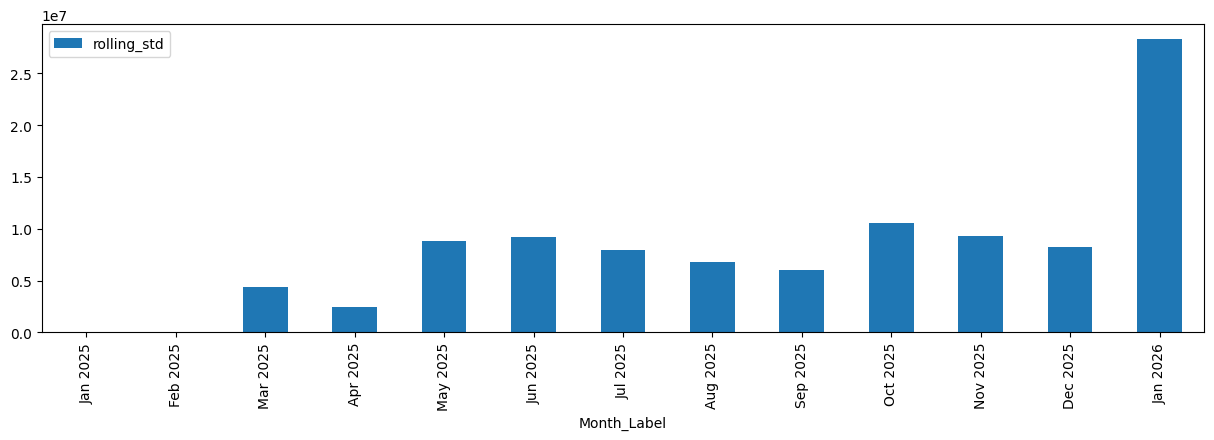

In [ ]:
# Weekly aggregation
monthly = (
    df.groupby('ISO Week Month', as_index=False)['Amount']
      .sum()
      .sort_values('ISO Week Month')
)

monthly['ISO Week Month'] = pd.to_datetime(monthly['ISO Week Month'],format='%b %Y')

monthly = monthly.sort_values('ISO Week Month')

monthly['Month_Label'] = monthly['ISO Week Month'].dt.strftime('%b %Y')


# Rolling std with ALL weeks included
window = 3
monthly['rolling_std'] = monthly['Amount'].rolling(
    window=window,
    min_periods=3
).std()

print(monthly)
monthly.plot(x='Month_Label', y='rolling_std', kind='bar',figsize=(15,4))

In [ ]:
df['Client_name'].nunique(dropna=False)

572

In [ ]:
df[df['Client_name'].isna()]


,Date,Period,Type,Document Number,Account,Amount,Amount (Foreign Currency),Currency,Customer Internal ID,Core Client ID,...,Month_Name,Month_Num,ISO Year-Week,ISO Week Anchor,ISO Week Month,ISO Week Month Sort,ISO Quarter,ISO Quarter Sort,Client_name,Entity_name
28135,12/03/2025,12/25/2026,Payment,PMT97044536105154522535925,10301,515.24,515.24,USD,32409529,NaN,...,Dec,12,2025-W49,45995,Dec 2025,202512,2025-Q4,20254,NaN,Entity_B924
29645,12/19/2025,12/25/2026,Payment,PMT97044536105154522538865,10309,4840.96,"4 128,79",EUR,32431144,NaN,...,Dec,12,2025-W51,46009,Dec 2025,202512,2025-Q4,20254,NaN,Entity_B939
29948,12/19/2025,12/25/2026,Payment,191298,10053,955.61,£714.17,GBP,32476567,NaN,...,Dec,12,2025-W51,46009,Dec 2025,202512,2025-Q4,20254,NaN,Entity_B941
30301,12/29/2025,12/25/2026,Payment,PMT97044536105154522540337,10301,9667.20,9667.2,USD,32409529,NaN,...,Dec,12,2026-W53,46023,Jan 2026,202601,2026-Q1,20261,NaN,Entity_B924
30334,12/24/2025,12/25/2026,Payment,192040,10051,8610.84,"7 299,55",EUR,32482197,NaN,...,Dec,12,2025-W52,46016,Dec 2025,202512,2025-Q4,20254,NaN,Entity_B944
30435,12/29/2025,12/25/2026,Payment,192402,10051,105100.05,"89 328,25",EUR,32483997,NaN,...,Dec,12,2026-W53,46023,Jan 2026,202601,2026-Q1,20261,NaN,Entity_B947
30538,12/30/2025,12/25/2026,Payment,192560,10051,37859.03,"32 155,05",EUR,32464852,NaN,...,Dec,12,2026-W53,46023,Jan 2026,202601,2026-Q1,20261,NaN,Entity_B948
30599,12/30/2025,12/25/2026,Payment,192579,10051,5201.09,"4 417,47",EUR,32482197,NaN,...,Dec,12,2026-W53,46023,Jan 2026,202601,2026-Q1,20261,NaN,Entity_B944
30623,12/30/2025,12/25/2026,Payment,192592,10051,3131.95,"2 660,08",EUR,32464852,NaN,...,Dec,12,2026-W53,46023,Jan 2026,202601,2026-Q1,20261,NaN,Entity_B948


In [ ]:
p = df.groupby('Client_name', as_index=False)['Amount'].sum().sort_values('Amount', ascending=False)
p['cum_pct'] = p['Amount'].cumsum() / p['Amount'].sum() * 100
p['amount in m'] = p['Amount'] / 1000000
p['rank'] = range(1, len(p) + 1)
p_top_10 = ['Client_name', 'amount in m', 'cum_pct', 'rank']
p[p_top_10].head(10)




,Client_name,amount in m,cum_pct,rank
530,Client_A62,32.066035,4.846637,1
356,Client_A42,25.340314,8.676712,2
222,Client_A3,23.997861,12.303881,3
532,Client_A64,22.014602,15.631289,4
550,Client_A80,21.437494,18.871470,5
527,Client_A6,21.100180,22.060668,6
456,Client_A51,16.815381,24.602237,7
144,Client_A229,12.839839,26.542921,8
143,Client_A228,11.390496,28.264543,9
433,Client_A49,11.104595,29.942953,10


Text(0.5, 1.0, 'Pareto Chart – Cash Inflows by Client')

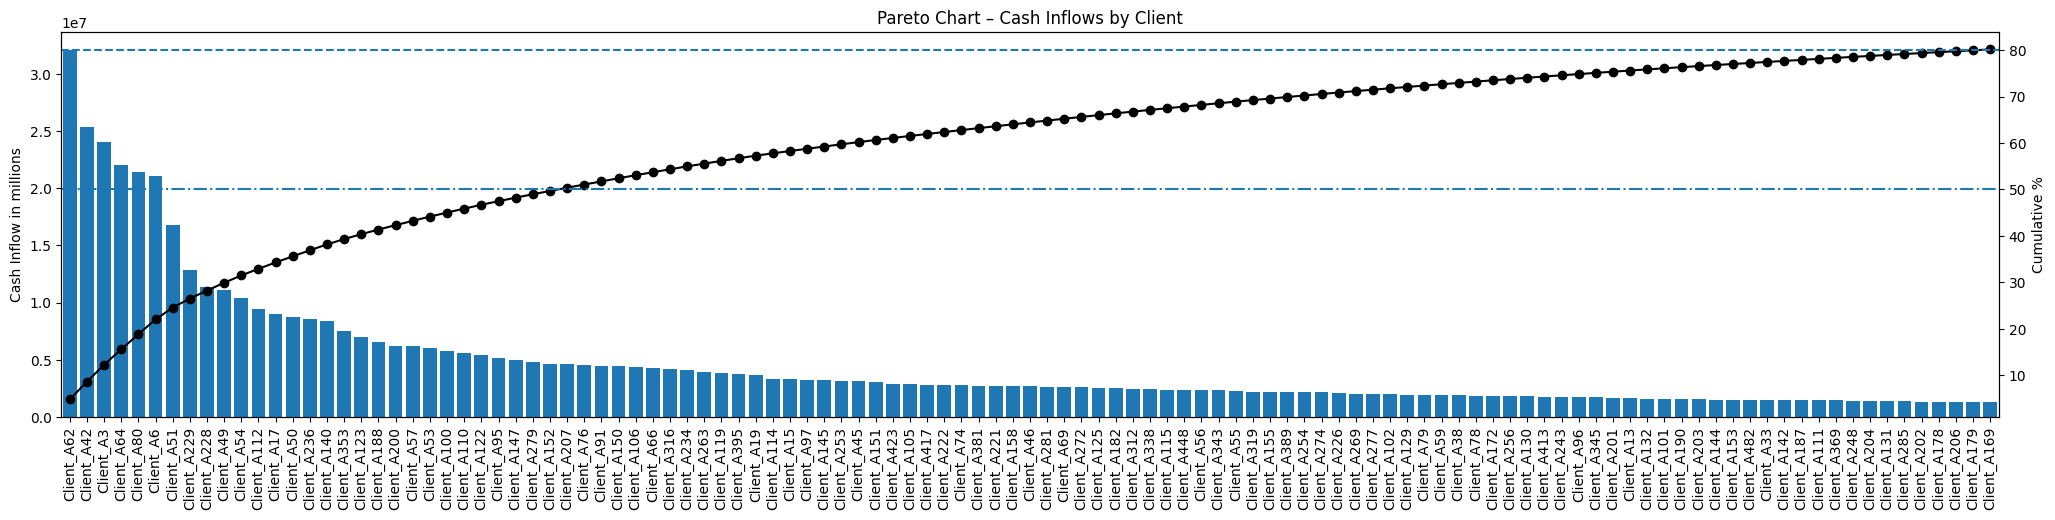

In [ ]:
p = df.groupby('Client_name', as_index=False)['Amount'].sum().sort_values('Amount', ascending=False)
p['cum_pct'] = p['Amount'].cumsum() / p['Amount'].sum() * 100
p_top = p.head(113)

fig, ax = plt.subplots(figsize=(25, 5))
ax.bar(p_top['Client_name'], p_top['Amount'])
ax.set_ylabel('Cash Inflow in millions')
ax.tick_params(axis='x', rotation=90)

ax2=ax.twinx()
ax2.plot(p_top['Client_name'], p_top['cum_pct'], color='black', marker='o')
ax2.set_ylabel('Cumulative %')

# 80% reference line

ax2.axhline(80, linestyle='--')
ax2.axhline(50, linestyle='dashdot')

ax.set_xlim(-0.5, len(p_top) - 0.5)
ax2.set_xlim(-0.5, len(p_top) - 0.5)



plt.title('Pareto Chart – Cash Inflows by Client')